### Tutorial 1 – Scalability and Synchronization


##### Task-1: Scaling of a Computer System

We create a simple model of a computer system. The following is a simple example from queuing theory. We assume that new jobs for the computer system come in with a constant rate of $\alpha$ and are added to a waiting list. We also assume that the process is without memory, that is, incoming jobs are statistically independent from each other. Therefore, we model the incoming jobs as a Poisson process. The probability that $i$ jobs arrive within a given time interval $\Delta t$ is given by:




$P(X = i) = \frac{e^{-\lambda}\lambda^i}{i!}$

for $\lambda = \alpha \Delta t$. In the following we simply set $\Delta t = 1$.


a) Plot $P(X = i)$ for a reasonable interval of $X$ and $\alpha \in \{0.01, 0.1, 0.5, 1\}$.

##### Task-2: Synchronization of a Swarm

Swarm systems are asynchronous systems. There is no central clock that could be accessed by
everyone. If a swarm needs to act in synchrony, it has to explicitly synchronize first. An example
of a biological system that shows synchronization is a population of fireflies (see Fig. 1)

In [ ]:
from IPython.display import Image, display

# Display the firefly swarm visualization
display(Image('task2a_flashing_patterns.png'))
display(Image('task2b_synchronization_quality.png'))


In the following we create a simple model of such a firefly population. The population is scattered randomly over a $1 \times 1$ square (uniform distribution). We assume that fireflies are stationary and can only perceive local neighbors in their vicinity. We say two fireflies are within the vicinity of each other if the distance between them is smaller than $r$. Hence, there is a virtual disc centered at each firefly’s position and every other firefly located within that disc is considered a neighbor.

The fireflies flash in cycles. We define the cycle length by $L = 50$ time steps. We initialize the fireflies to uniformly randomly distributed clock cycles (i.e., not synchronized). The firefly flashes for $L/2$ steps followed by $L/2$ steps of not flashing. This holds except when the firefly attempts to correct its cycle to synchronize. In the time step after it has started to flash it checks its neighbors and tests whether the majority of them is actually already flashing. If so, the firefly corrects its clock by adding 1, that is, it is decreasing the current flashing cycle from $L/2$ to $L/2 - 1$ steps and will consequently flash 1 step earlier next time.

a) Implement the model for swarm size $N = 150$ and cycle length $L = 50$. Calculate the average number of neighbors per firefly for vicinity distances $r \in \{0.05, 0.1, 0.5, 1.4\}$. Plot the number of currently flashing fireflies over time for vicinity distances $r \in \{0.05, 0.1, 0.5, 1.4\}$ for 5000 time steps each. When plotting the number of currently flashing flies, make sure you plot the full interval of $[0, 150]$ for the vertical axis.

b) Extend your model to determine the minimum and maximum number of concurrently flashing fireflies during the very last cycle (last $L = 50$ time steps starting from $t = 4950$). By subtracting the minimum from the maximum you get twice the amplitude of the flash cycle. Average the measured amplitudes over 50 samples each (50 independent simulation runs with 5000 time steps each) and plot them over vicinities $r \in [0.025, 1.4]$ in steps of 0.025. What seems to be a good choice for the vicinity and the swarm density? What do low amplitudes tell us about synchronization, and what do high amplitudes reveal?

TASK 2a: Firefly Synchronization

Simulating with vicinity radius r = 0.05
  Average neighbors per firefly: 1.16

Simulating with vicinity radius r = 0.1
  Average neighbors per firefly: 4.32

Simulating with vicinity radius r = 0.5
  Average neighbors per firefly: 71.93

Simulating with vicinity radius r = 1.4
  Average neighbors per firefly: 149.00

✓ Plot saved as 'task2a_flashing_patterns.png'


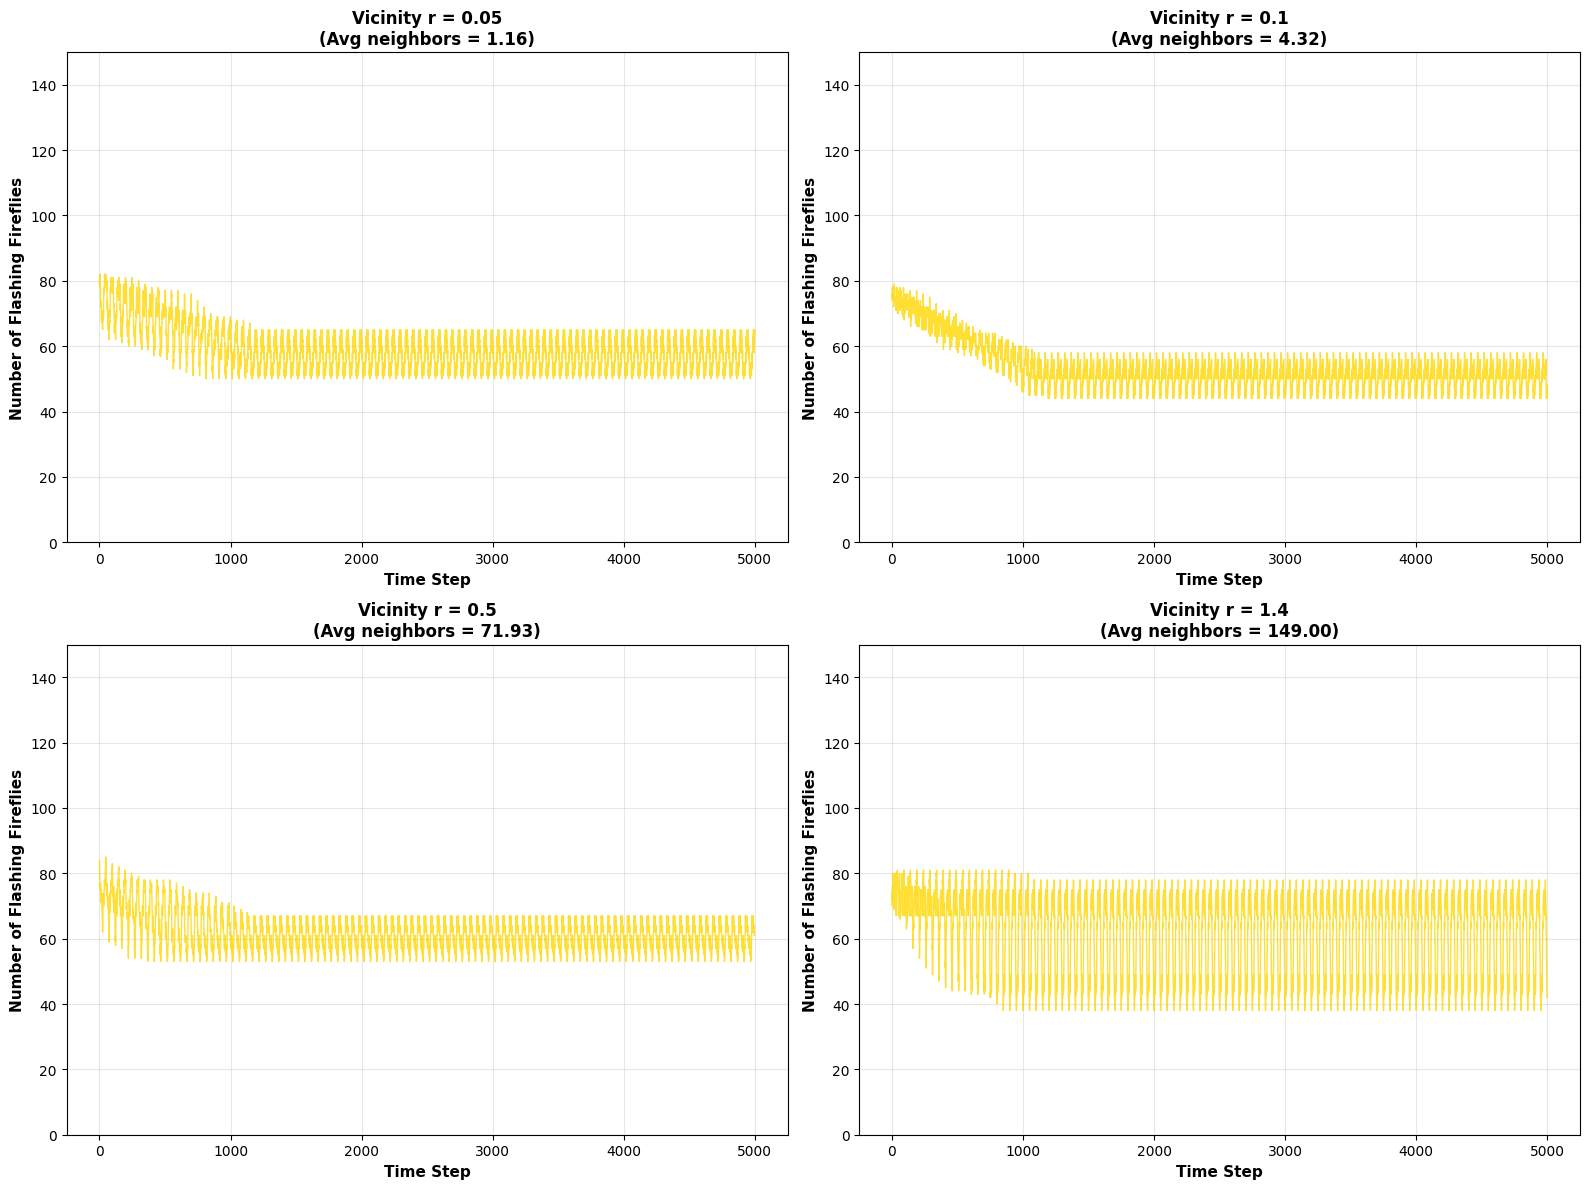


TASK 2b: Synchronization Quality Analysis
Running 50 simulations per vicinity radius
Vicinity range: 0.025 to 1.400
Total simulations: 2800



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# FIREFLY CLASS
# ============================================================================

class Firefly:
    """A single firefly agent in the swarm."""
    
    def __init__(self, x, y, cycle_length=50):
        self.x = x
        self.y = y
        self.cycle_length = cycle_length
        self.cycle_position = np.random.randint(0, cycle_length)
        self.flash_threshold = cycle_length / 2  # L/2 = 25
    
    def distance_to(self, other_firefly):
        """Calculate Euclidean distance to another firefly."""
        dx = self.x - other_firefly.x
        dy = self.y - other_firefly.y
        return np.sqrt(dx**2 + dy**2)
    
    def is_flashing(self):
        """True if firefly is in flashing phase."""
        return self.cycle_position < self.flash_threshold
    
    def get_neighbors(self, all_fireflies, vicinity_radius):
        """Find all neighbors within vicinity_radius."""
        neighbors = []
        for other in all_fireflies:
            if other is self:
                continue
            distance = self.distance_to(other)
            if distance < vicinity_radius:
                neighbors.append(other)
        return neighbors
    
    def step(self, all_fireflies, vicinity_radius):
        """Execute one time step: check sync condition and advance cycle."""
        # Just started flashing?
        if self.cycle_position == 0:
            neighbors = self.get_neighbors(all_fireflies, vicinity_radius)
            
            if len(neighbors) > 0:
                flashing_neighbors = sum(1 for n in neighbors if n.is_flashing())
                
                # If majority are flashing, speed up
                if flashing_neighbors > len(neighbors) / 2:
                    self.flash_threshold = max(1, self.flash_threshold - 1)
        
        # Advance cycle
        self.cycle_position = (self.cycle_position + 1) % self.cycle_length

# ============================================================================
# SWARM CLASS
# ============================================================================

class FireflySwarm:
    """Manages a population of fireflies."""
    
    def __init__(self, num_fireflies=150, cycle_length=50):
        self.num_fireflies = num_fireflies
        self.cycle_length = cycle_length
        self.fireflies = [
            Firefly(
                x=np.random.uniform(0, 1),
                y=np.random.uniform(0, 1),
                cycle_length=cycle_length
            )
            for _ in range(num_fireflies)
        ]
        self.flashing_counts = []
    
    def get_average_neighbors(self, vicinity_radius):
        """Calculate average number of neighbors per firefly."""
        total_neighbors = 0
        for firefly in self.fireflies:
            neighbors = firefly.get_neighbors(self.fireflies, vicinity_radius)
            total_neighbors += len(neighbors)
        return total_neighbors / self.num_fireflies
    
    def step(self, vicinity_radius):
        """Execute one time step for entire swarm."""
        for firefly in self.fireflies:
            firefly.step(self.fireflies, vicinity_radius)
        
        flashing_count = sum(1 for f in self.fireflies if f.is_flashing())
        self.flashing_counts.append(flashing_count)
    
    def simulate(self, num_steps, vicinity_radius):
        """Run simulation for num_steps time steps."""
        self.flashing_counts = []
        for step in range(num_steps):
            self.step(vicinity_radius)

# ============================================================================
# HELPER FUNCTION
# ============================================================================

def measure_flash_amplitude(flashing_counts, cycle_length=50):
    """
    Measure synchronization quality using flash amplitude.
    Amplitude = Max - Min in last cycle.
    """
    last_cycle_start = len(flashing_counts) - cycle_length
    last_cycle = flashing_counts[last_cycle_start:]
    
    min_flashing = min(last_cycle)
    max_flashing = max(last_cycle)
    amplitude = max_flashing - min_flashing
    
    return amplitude

# ============================================================================
# TASK 2a: BASIC IMPLEMENTATION
# ============================================================================

def task_2a():
    """Plot flashing patterns for different vicinity radii."""
    
    N = 150
    L = 50
    vicinity_radii = [0.05, 0.1, 0.5, 1.4]
    num_steps = 5000
    
    print("="*70)
    print("TASK 2a: Firefly Synchronization")
    print("="*70)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    results_2a = {}
    
    for idx, r in enumerate(vicinity_radii):
        print(f"\nSimulating with vicinity radius r = {r}")
        
        swarm = FireflySwarm(num_fireflies=N, cycle_length=L)
        avg_neighbors = swarm.get_average_neighbors(r)
        print(f"  Average neighbors per firefly: {avg_neighbors:.2f}")
        
        swarm.simulate(num_steps, r)
        
        ax = axes[idx]
        ax.plot(swarm.flashing_counts, linewidth=1, color='gold', alpha=0.8)
        ax.set_ylim([0, 150])
        ax.set_xlabel('Time Step', fontsize=11, fontweight='bold')
        ax.set_ylabel('Number of Flashing Fireflies', fontsize=11, fontweight='bold')
        ax.set_title(f'Vicinity r = {r}\n(Avg neighbors = {avg_neighbors:.2f})', 
                     fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)
        
        results_2a[r] = {
            'avg_neighbors': avg_neighbors,
            'flashing_counts': swarm.flashing_counts
        }
    
    plt.tight_layout()
    plt.savefig('task2a_flashing_patterns.png', dpi=300, bbox_inches='tight')
    print("\n✓ Plot saved as 'task2a_flashing_patterns.png'")
    plt.show()
    
    return results_2a

# ============================================================================
# TASK 2b: SYNCHRONIZATION QUALITY ANALYSIS
# ============================================================================

def task_2b():
    """Measure synchronization quality across vicinity radii."""
    
    N = 150
    L = 50
    num_steps = 5000
    num_simulations = 50
    
    vicinity_values = np.arange(0.025, 1.425, 0.025)
    
    print("\n" + "="*70)
    print("TASK 2b: Synchronization Quality Analysis")
    print("="*70)
    print(f"Running {num_simulations} simulations per vicinity radius")
    print(f"Vicinity range: {vicinity_values[0]:.3f} to {vicinity_values[-1]:.3f}")
    print(f"Total simulations: {num_simulations * len(vicinity_values)}\n")
    
    average_amplitudes = []
    
    for r_idx, r in enumerate(vicinity_values):
        amplitudes_for_this_r = []
        
        for sim in range(num_simulations):
            swarm = FireflySwarm(num_fireflies=N, cycle_length=L)
            swarm.simulate(num_steps, r)
            amplitude = measure_flash_amplitude(swarm.flashing_counts, L)
            amplitudes_for_this_r.append(amplitude)
        
        avg_amplitude = np.mean(amplitudes_for_this_r)
        average_amplitudes.append(avg_amplitude)
        
        if (r_idx + 1) % 10 == 0:
            print(f"Progress: {r_idx + 1}/{len(vicinity_values)} completed | " +
                  f"r = {r:.3f}: amplitude = {avg_amplitude:.2f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(vicinity_values, average_amplitudes, linewidth=2.5, 
            marker='o', markersize=6, color='steelblue', label='Average amplitude')
    
    optimal_r_idx = np.argmin(average_amplitudes)
    optimal_r = vicinity_values[optimal_r_idx]
    min_amplitude = average_amplitudes[optimal_r_idx]
    
    ax.axvline(x=optimal_r, color='red', linestyle='--', linewidth=2, alpha=0.7,
               label=f'Optimal r = {optimal_r:.3f} (amplitude = {min_amplitude:.2f})')
    
    ax.set_xlabel('Vicinity Radius (r)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Flash Amplitude (Max - Min)', fontsize=13, fontweight='bold')
    ax.set_title('Synchronization Quality: Effect of Vicinity Radius\n' + 
                 '(50 independent simulations per radius)',
                 fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig('task2b_synchronization_quality.png', dpi=300, bbox_inches='tight')
    print("\n✓ Plot saved as 'task2b_synchronization_quality.png'")
    plt.show()
    
    # Analysis
    print("\n" + "="*70)
    print("ANALYSIS")
    print("="*70)
    print(f"Optimal vicinity radius: r = {optimal_r:.3f}")
    print(f"Minimum average amplitude: {min_amplitude:.2f}")
    print(f"\nWhat low amplitudes tell us:")
    print(f"  • Low amplitude = good synchronization")
    print(f"  • Fireflies flash together nearly in sync")
    print(f"  • Most fireflies light up at same time")
    print(f"\nWhat high amplitudes reveal:")
    print(f"  • High amplitude = poor synchronization")
    print(f"  • Fireflies out of phase with each other")
    print(f"  • Scattered, chaotic flashing pattern")
    
    swarm = FireflySwarm(num_fireflies=N, cycle_length=L)
    optimal_neighbors = swarm.get_average_neighbors(optimal_r)
    print(f"\nOptimal connectivity:")
    print(f"  • Average neighbors at optimal r: {optimal_neighbors:.2f}")
    print(f"  • Percentage of swarm: {optimal_neighbors/N*100:.1f}%")
    
    return vicinity_values, average_amplitudes, optimal_r

# ============================================================================
# RUN EVERYTHING
# ============================================================================

if __name__ == "__main__":
    # Task 2a
    results_2a = task_2a()
    
    # Task 2b
    vicinity_values, average_amplitudes, optimal_r = task_2b()